In [33]:
import pandas as pd
from nltk.corpus import stopwords
import string
import re
from nltk.tokenize import RegexpTokenizer
import nltk
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from scipy.stats import uniform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay




In [34]:
columns = ['target','ids','date','flag','user','text']
df = pd.read_csv("training.1600000.processed.noemoticon.csv",encoding='ISO-8859-1', names=columns)

In [35]:
df.sample(6)


,target,ids,date,flag,user,text
525939,0,2194091863,Tue Jun 16 09:20:01 PDT 2009,NO_QUERY,RubyyG,@carolilah im takeing regents too
1217426,4,1989732431,Mon Jun 01 02:36:48 PDT 2009,NO_QUERY,CoffeebreakDMV,"@patrikianpolk LOL, you were looking for Tyler..."
768514,0,2301025948,Tue Jun 23 14:54:12 PDT 2009,NO_QUERY,shelbaayy,god my stomach hurrrtsss. ugggh. hmm well get...
111325,0,1825096875,Sun May 17 04:19:53 PDT 2009,NO_QUERY,a_s_h_xo,"is off to bed, another week of school ahead xo"
1068614,4,1965769147,Fri May 29 16:30:36 PDT 2009,NO_QUERY,juliaamariee,http://twitpic.com/67uzq - Mmm. Two of my favo...
881827,4,1685871875,Sun May 03 02:31:39 PDT 2009,NO_QUERY,stormsage,@kathleenishness congrats on passing the eng t...


Sentiment label distribution:
target
0    800000
4    800000
Name: count, dtype: int64


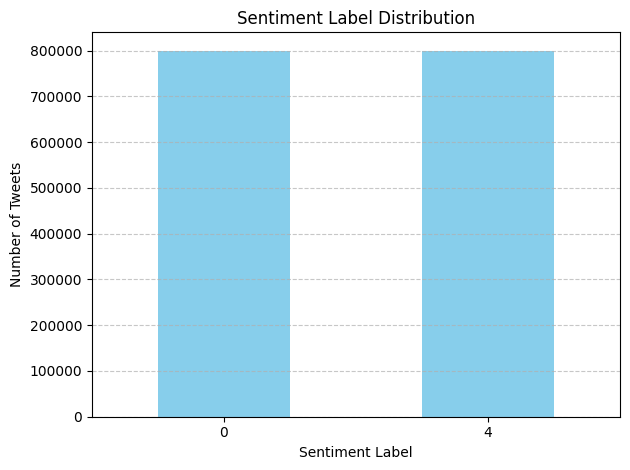


Sample tweets:
514293    i miss nikki nu nu already  shes always there ...
142282    So I had a dream last night. I  remember a sig...
403727    @girlyghost ohh poor sickly you   (((hugs)) ho...
649503                                 it is raining again 
610789            @MissKeriBaby wish I was in LA right now 
Name: text, dtype: object


In [36]:
label_counts = df['target'].value_counts().sort_index()
print("Sentiment label distribution:")
print(label_counts)


label_counts.plot(kind='bar', color='skyblue')
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nSample tweets:")
print(df['text'].sample(5, random_state=1))

In [37]:
df.isna().sum()

target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64

In [38]:
df['target'].unique()

array([0, 4], dtype=int64)

In [39]:
data=df[['text','target']]


In [40]:
data['target'] = data['target'].replace(4,1)

C:\Users\hwi\AppData\Local\Temp\ipykernel_6356\2499609609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['target'] = data['target'].replace(4,1)


In [41]:
data

,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0
...,...,...
1599995,Just woke up. Having no school is the best fee...,1
1599996,TheWDB.com - Very cool to hear old Walt interv...,1
1599997,Are you ready for your MoJo Makeover? Ask me f...,1
1599998,Happy 38th Birthday to my boo of alll time!!! ...,1


In [42]:
data_p = data[data['target'] == 1]
data_n = data[data['target'] == 0]
data_p = data_p.iloc[:int(20000)]
data_n = data_n.iloc[:int(20000)]
df = pd.concat([data_p, data_n])
df.shape 

(40000, 2)

In [43]:
df['text']=df['text'].str.lower()
df.head()

,text,target
800000,i love @health4uandpets u guys r the best!!,1
800001,im meeting up with one of my besties tonight! ...,1
800002,"@darealsunisakim thanks for the twitter add, s...",1
800003,being sick can be really cheap when it hurts t...,1
800004,@lovesbrooklyn2 he has that effect on everyone,1


In [44]:
stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from',
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're','s',
               'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves']

In [45]:
def remove_stopwords(text):
    new_text = []
    
    for word in text.split():
        if word in stopwords.words('english'):
            new_text.append('')
        else:
            new_text.append(word)
    x = new_text[:]
    new_text.clear()
    return " ".join(x)

In [46]:
df['text'] = df['text'].apply(remove_stopwords)


In [47]:
english_punctuations = string.punctuation
punctuations_list = english_punctuations
def cleaning_punctuations(text):
    translator = str.maketrans('', '', punctuations_list)
    return text.translate(translator)
df['text']= df['text'].apply(lambda x: cleaning_punctuations(x))
df['text'].tail()

19995     much time   weekend work trip  malmï¿½ frisat...
19996                                   one  day  holidays
19997                feeling   right    hate  damn humprey
19998    geezi hv  read  whole book  personality types ...
19999     threw  sign  donnie   bent   get       thinge...
Name: text, dtype: object

In [48]:
df.sample(6)

,text,target
814840,difference referee battery battery pos...,1
3958,cold,0
19810,keaicutie oh take care cutie,0
808023,jemimahknight loved podcast thank,1
801315,asurana welcome used aptana gt6 months let...,1
807617,nuggetstump hey texas cold music going goo...,1


In [49]:
def cleaning_repeating_char(text):
    return re.sub(r'(.)1+', r'1', text)
df['text'] = df['text'].apply(lambda x: cleaning_repeating_char(x))
df['text'].tail()


19995     much time   weekend work trip  malmï¿½ frisat...
19996                                   one  day  holidays
19997                feeling   right    hate  damn humprey
19998    geezi hv  read  whole book  personality types ...
19999     threw  sign  donnie   bent   get       thinge...
Name: text, dtype: object

In [50]:
def cleaning_URLs(data):
    return re.sub('((www.[^s]+)|(https?://[^s]+))',' ',data)
df['text'] = df['text'].apply(lambda x: cleaning_URLs(x))
df['text'].tail()

19995     much time   weekend work trip  malmï¿½ frisat...
19996                                   one  day  holidays
19997                feeling   right    hate  damn humprey
19998    geezi hv  read  whole book  personality types ...
19999     threw  sign  donnie   bent   get       thinge...
Name: text, dtype: object

In [51]:
def cleaning_numbers(data):
    return re.sub('[0-9]+', '', data)
df['text'] = df['text'].apply(lambda x: cleaning_numbers(x))
df['text'].tail()

19995     much time   weekend work trip  malmï¿½ frisat...
19996                                   one  day  holidays
19997                feeling   right    hate  damn humprey
19998    geezi hv  read  whole book  personality types ...
19999     threw  sign  donnie   bent   get       thinge...
Name: text, dtype: object

In [52]:
tokenizer = RegexpTokenizer('\s+', gaps = True)
df['text'] = df['text'].apply(tokenizer.tokenize)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\hwi\AppData\Local\Temp\ipykernel_6356\2193711807.py:1: SyntaxWarning: invalid escape sequence '\s'
  tokenizer = RegexpTokenizer('\s+', gaps = True)


In [53]:
df['text'].tail()


19995    [much, time, weekend, work, trip, malmï¿½, fri...
19996                                 [one, day, holidays]
19997                [feeling, right, hate, damn, humprey]
19998    [geezi, hv, read, whole, book, personality, ty...
19999    [threw, sign, donnie, bent, get, thingee, made...
Name: text, dtype: object

In [54]:
st = nltk.PorterStemmer()
def stemming_on_text(data):
    text = [st.stem(word) for word in data]
    return data
df['text']= df['text'].apply(lambda x: stemming_on_text(x))
df['text'].head()

800000             [love, healthuandpets, u, guys, r, best]
800001    [im, meeting, one, besties, tonight, cant, wai...
800002    [darealsunisakim, thanks, twitter, add, sunisa...
800003    [sick, really, cheap, hurts, much, eat, real, ...
800004                    [lovesbrooklyn, effect, everyone]
Name: text, dtype: object

In [55]:
lm = nltk.WordNetLemmatizer()
def lemmatizer_on_text(data):
    text = [lm.lemmatize(word) for word in data]
    return data
df['text'] = df['text'].apply(lambda x: lemmatizer_on_text(x))
df['text'].head()

800000             [love, healthuandpets, u, guys, r, best]
800001    [im, meeting, one, besties, tonight, cant, wai...
800002    [darealsunisakim, thanks, twitter, add, sunisa...
800003    [sick, really, cheap, hurts, much, eat, real, ...
800004                    [lovesbrooklyn, effect, everyone]
Name: text, dtype: object

In [56]:
df[df['target']==0]['text']


0        [switchfoot, httptwitpiccomzl, a, s, bummer, s...
1        [upset, cant, update, facebook, texting, it, m...
2        [kenichan, dived, many, times, ball, managed, ...
3                  [whole, body, feels, itchy, like, fire]
4        [nationwideclass, no, behaving, all, im, mad, ...
                               ...                        
19995    [much, time, weekend, work, trip, malmï¿½, fri...
19996                                 [one, day, holidays]
19997                [feeling, right, hate, damn, humprey]
19998    [geezi, hv, read, whole, book, personality, ty...
19999    [threw, sign, donnie, bent, get, thingee, made...
Name: text, Length: 20000, dtype: object

In [57]:
ndata=df
ndata['text'] = df['text'].apply(lambda x: ' '.join(x) )
ndata.head()

,text,target
800000,love healthuandpets u guys r best,1
800001,im meeting one besties tonight cant wait girl ...,1
800002,darealsunisakim thanks twitter add sunisa got ...,1
800003,sick really cheap hurts much eat real food plu...,1
800004,lovesbrooklyn effect everyone,1


In [58]:
X=ndata.text
y=ndata.target

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=0
)

In [60]:
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
vectoriser.fit(X_train)
print('No. of feature_words: ', len(vectoriser.get_feature_names_out()))

No. of feature_words:  5000


In [61]:
X_train = vectoriser.transform(X_train)
X_test  = vectoriser.transform(X_test)

In [62]:
from sklearn.svm import SVC
clf=SVC()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [63]:
kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    print(f"\n Testing kernel: {kernel}")
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {kernel} kernel: {acc:.4f}")
    print(classification_report(y_test, y_pred))



 Testing kernel: linear
Accuracy for linear kernel: 0.7400
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      4000
           1       0.73      0.76      0.75      4000

    accuracy                           0.74      8000
   macro avg       0.74      0.74      0.74      8000
weighted avg       0.74      0.74      0.74      8000


 Testing kernel: rbf
Accuracy for rbf kernel: 0.7442
              precision    recall  f1-score   support

           0       0.76      0.72      0.74      4000
           1       0.73      0.77      0.75      4000

    accuracy                           0.74      8000
   macro avg       0.74      0.74      0.74      8000
weighted avg       0.74      0.74      0.74      8000


 Testing kernel: poly
Accuracy for poly kernel: 0.7232
              precision    recall  f1-score   support

           0       0.73      0.71      0.72      4000
           1       0.72      0.73      0.73      4000

    accuracy

In [64]:

test_acc=accuracy_score(y_test,y_pred)
print(test_acc)
cfm=confusion_matrix(y_test,y_pred)
print(cfm)

0.72325
[[2858 1142]
 [1072 2928]]


In [ ]:
svc = SVC()


param_dist = {
    'kernel': ['linear', 'rbf', 'poly'],      
    'C': uniform(0.1, 5),                    
    'gamma': uniform(0.01, 0.5)                
}

random_search = RandomizedSearchCV(
    svc,
    param_distributions=param_dist,
    n_iter=5,               
    scoring='accuracy',
    cv=2,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)


y_pred = random_search.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters: {'C': 0.38205789513550126, 'gamma': 0.3709993861334124, 'kernel': 'rbf'}
Best CV Score: 0.73428125
Test Accuracy: 0.740625
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      4000
           1       0.72      0.78      0.75      4000

    accuracy                           0.74      8000
   macro avg       0.74      0.74      0.74      8000
weighted avg       0.74      0.74      0.74      8000



In [ ]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')  
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print(" Evaluation Metrics on Test Set:")
print(f" Accuracy :  {accuracy:.4f}")
print(f" Precision:  {precision:.4f}")
print(f" Recall   :  {recall:.4f}")
print(f" F1-Score :  {f1:.4f}")




 Evaluation Metrics on Test Set:
 Accuracy :  0.7406
 Precision:  0.7224
 Recall   :  0.7815
 F1-Score :  0.7508

📝 Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      4000
           1       0.72      0.78      0.75      4000

    accuracy                           0.74      8000
   macro avg       0.74      0.74      0.74      8000
weighted avg       0.74      0.74      0.74      8000



In [67]:

report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])
print(report)


              precision    recall  f1-score   support

    Negative       0.76      0.70      0.73      4000
    Positive       0.72      0.78      0.75      4000

    accuracy                           0.74      8000
   macro avg       0.74      0.74      0.74      8000
weighted avg       0.74      0.74      0.74      8000

